In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/seven-datasets-for-classification-test-on-tabpfn/Classification DataSets/blood_transfusion-service-center.csv
/kaggle/input/seven-datasets-for-classification-test-on-tabpfn/Classification DataSets/car.csv
/kaggle/input/seven-datasets-for-classification-test-on-tabpfn/Classification DataSets/ada_dataset.csv
/kaggle/input/seven-datasets-for-classification-test-on-tabpfn/Classification DataSets/cmc.csv
/kaggle/input/seven-datasets-for-classification-test-on-tabpfn/Classification DataSets/australian_dataset.csv
/kaggle/input/seven-datasets-for-classification-test-on-tabpfn/Classification DataSets/chum.csv
/kaggle/input/seven-datasets-for-classification-test-on-tabpfn/Classification DataSets/credit-g.csv
/kaggle/input/heart-disease-dataset/heart.csv


In [2]:
# Install dependencies
!pip install tabpfn autogluon catboost lightgbm xgboost pandas numpy matplotlib seaborn
!git clone https://github.com/PriorLabs/tabpfn-extensions
!pip install -e tabpfn-extensions[all]
!pip install scikit-learn==1.5.2
!pip install "tabpfn-extensions[all] @ git+https://github.com/PriorLabs/tabpfn-extensions.git"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of thinc to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.5/259.5 kB 10.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of openxlab to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of openxlab to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to

In [3]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas_profiling import ProfileReport
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import catboost as cb
import lightgbm as lgb
import xgboost as xgb

# Optional imports with fallbacks
# AutoGluon
try:
    from autogluon.tabular import TabularPredictor
    AGLUON_AVAILABLE = True
except ImportError as e:
    print("Warning: AutoGluon import failed:", e)
    AGLUON_AVAILABLE = False

# TabPFN
from tabpfn import TabPFNClassifier
# try:
#   from tabpfn_extensions.post_hoc_ensembles.sklearn_interface import AutoTabPFNClassifier, AutoTabPFNRegressor
# except:
#   raise SystemError('Please restart the session to fix this import.')

/tmp/ipykernel_36/3145687494.py:5: DeprecationWarning: `import pandas_profiling` is going to be deprecated by April 1st. Please use `import ydata_profiling` instead.
  from pandas_profiling import ProfileReport


In [4]:
# 3) Load dataset (update the file path as needed)
# heart-disease-dataset = '/kaggle/input/heart-disease-dataset'
# df = pd.read_csv(heart-disease-dataset)

# ada_dataset = '/kaggle/input/seven-datasets-for-classification-test-on-tabpfn/Classification DataSets/ada_dataset.csv'
# df = pd.read_csv(ada_dataset)

australian_dataset = '/kaggle/input/seven-datasets-for-classification-test-on-tabpfn/Classification DataSets/australian_dataset.csv'
df = pd.read_csv(australian_dataset)

# blood_transfusion-service-center_dataset = '/kaggle/input/seven-datasets-for-classification-test-on-tabpfn/Classification DataSets/blood_transfusion-service-center.csv'
# df = pd.read_csv(blood_transfusion-service-center_dataset)

# car_dataset = '/kaggle/input/seven-datasets-for-classification-test-on-tabpfn/Classification DataSets/car.csv'
# df = pd.read_csv(car_dataset)

# chum_dataset = '/kaggle/input/seven-datasets-for-classification-test-on-tabpfn/Classification DataSets/chum.csv'
# df = pd.read_csv(chum_dataset)

# cmc_dataset = '/kaggle/input/seven-datasets-for-classification-test-on-tabpfn/Classification DataSets/cmc.csv'
# df = pd.read_csv(cmc_dataset)

# credit-g_dataset = '/kaggle/input/seven-datasets-for-classification-test-on-tabpfn/Classification DataSets/credit-g.csv'
# df = pd.read_csv(credit-g_dataset)

In [5]:
# 4) Dataset overview and information
print("Shape of the dataset:", df.shape)
df.info()
print("\nFirst few rows:")
display(df.head())
print("\nLast few rows:")
display(df.tail())
print("\nDescriptive statistics:")
display(df.describe(include='all').T)
print("\nMissing values per column:")
display(df.isnull().sum().sort_values(ascending=False))
print("\nMemory usage per column:")
display(df.memory_usage(deep=True))
print("\nUnique value counts per column:")
display(df.nunique())
print("\nData types of each column:")
display(df.dtypes)

Shape of the dataset: (690, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   A1      690 non-null    int64
 1   A2      690 non-null    int64
 2   A3      690 non-null    int64
 3   A4      690 non-null    int64
 4   A5      690 non-null    int64
 5   A6      690 non-null    int64
 6   A7      690 non-null    int64
 7   A8      690 non-null    int64
 8   A9      690 non-null    int64
 9   A10     690 non-null    int64
 10  A11     690 non-null    int64
 11  A12     690 non-null    int64
 12  A13     690 non-null    int64
 13  A14     690 non-null    int64
 14  target  690 non-null    int64
dtypes: int64(15)
memory usage: 81.0 KB

First few rows:


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,target
0,1,65,168,2,4,4,39,0,0,1,1,2,32,161,0
1,0,72,123,2,8,4,5,0,0,1,0,2,53,1,0
2,0,142,52,1,4,4,31,0,0,1,1,2,98,1,0
3,0,60,169,1,5,3,1,1,1,12,1,2,1,1,1
4,1,44,134,2,6,4,46,1,1,15,0,2,18,68,1



Last few rows:


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,target
685,1,163,160,2,14,4,99,1,0,1,0,2,1,1,1
686,1,49,14,2,8,4,4,0,0,1,0,2,1,35,0
687,0,32,145,2,6,4,3,1,0,1,0,2,32,1,1
688,0,122,193,2,14,8,67,1,1,2,0,2,38,12,1
689,1,245,2,2,10,4,2,0,1,2,0,1,159,1,1



Descriptive statistics:


...

Index      132
A1        5520
A2        5520
A3        5520
A4        5520
A5        5520
A6        5520
A7        5520
A8        5520
A9        5520
A10       5520
A11       5520
A12       5520
A13       5520
A14       5520
target    5520
dtype: int64


Unique value counts per column:


A1          2
A2        350
A3        215
A4          3
A5         14
A6          8
A7        132
A8          2
A9          2
A10        23
A11         2
A12         3
A13       171
A14       240
target      2
dtype: int64


Data types of each column:


A1        int64
A2        int64
A3        int64
A4        int64
A5        int64
A6        int64
A7        int64
A8        int64
A9        int64
A10       int64
A11       int64
A12       int64
A13       int64
A14       int64
target    int64
dtype: object

In [6]:
# # 6) Generate an interactive profiling report (optional)
# profile = ProfileReport(df, title="Profiling Report", explorative=True)
# profile.to_notebook_iframe()

### 5. Separate target and features

In [7]:
# Keep target vector separate from X
target = 'target'
if target not in df.columns:
    raise KeyError(f"Target column '{target}' not found in dataframe.")
y = df[target]
X = df.drop(columns=target)

## **5. Data processing**

In [8]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [9]:
# 6.1) Identify numerical and categorical columns in X
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

# 6.2) Handle missing values
num_imputer = SimpleImputer(strategy='median')
X[num_cols] = num_imputer.fit_transform(X[num_cols])
if cat_cols:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    X[cat_cols] = cat_imputer.fit_transform(X[cat_cols])

# 6.3) One-hot encode for processed dataset
if cat_cols:
    X_processed = pd.get_dummies(X, columns=cat_cols, drop_first=True)
else:
    X_processed = X.copy()

# 6.4) Z-normalization on processed numeric features
scaled_cols = [col for col in num_cols if col in X_processed.columns]
X_processed[scaled_cols] = X_processed[scaled_cols].apply(lambda col: (col - col.mean()) / col.std())

# 6.5) Raw encoded features (no scaling)
if cat_cols:
    X_raw = pd.get_dummies(X, columns=cat_cols, drop_first=True)
else:
    X_raw = X.copy()

In [10]:
# 6.4) Z-normalization on processed numeric features
scaled_cols = [col for col in num_cols if col in X_processed.columns]
X_processed[scaled_cols] = X_processed[scaled_cols].apply(lambda col: (col - col.mean()) / col.std())

In [11]:
# 6.5) Raw encoded features (no scaling)
if cat_cols:
    X_raw = pd.get_dummies(X, columns=cat_cols, drop_first=True)
else:
    X_raw = X.copy()

In [12]:
# 7) Train-test split on processed and raw data
processed_X_train, processed_X_test, processed_y_train, processed_y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42
)
print("Processed train/test shapes:", processed_X_train.shape, processed_X_test.shape)

raw_X_train, raw_X_test, raw_y_train, raw_y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42
)
print("Raw encoded train/test shapes:", raw_X_train.shape, raw_X_test.shape)

Processed train/test shapes: (552, 14) (138, 14)
Raw encoded train/test shapes: (552, 14) (138, 14)


In [13]:
raw_X_train.head(5)

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14
278,1.0,177.0,66.0,2.0,13.0,8.0,63.0,1.0,1.0,7.0,0.0,2.0,53.0,183.0
110,1.0,222.0,154.0,1.0,4.0,4.0,4.0,0.0,0.0,1.0,0.0,2.0,53.0,1.0
82,0.0,29.0,151.0,2.0,2.0,4.0,11.0,0.0,0.0,1.0,0.0,2.0,24.0,34.0
51,1.0,53.0,90.0,1.0,3.0,8.0,2.0,0.0,0.0,1.0,0.0,2.0,45.0,50.0
218,1.0,38.0,11.0,2.0,4.0,4.0,8.0,0.0,0.0,1.0,0.0,2.0,98.0,103.0


In [14]:
processed_X_train.head(5)

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14
278,0.688238,0.304664,-0.283753,0.542556,1.527866,1.660001,0.711616,0.953958,1.156306,0.917469,-0.918529,0.237655,-0.125614,1.758806
110,0.688238,0.788889,1.213033,-1.782685,-0.915618,-0.347713,-0.912439,-1.046745,-0.863570,-0.569736,-0.918529,0.237655,-0.125614,-0.744803
82,-1.450880,-1.287897,1.162006,0.542556,-1.458615,-0.347713,-0.719754,-1.046745,-0.863570,-0.569736,-0.918529,0.237655,-0.753997,-0.290852
51,0.688238,-1.029644,0.124461,-1.782685,-1.187116,1.660001,-0.967491,-1.046745,-0.863570,-0.569736,-0.918529,0.237655,-0.298961,-0.070754
218,0.688238,-1.191053,-1.219245,0.542556,-0.915618,-0.347713,-0.802333,-1.046745,-0.863570,-0.569736,-0.918529,0.237655,0.849463,0.658319


In [15]:
processed_y_train.head(5)

278    1
110    0
82     0
51     0
218    0
Name: target, dtype: int64

In [16]:
raw_y_train.head(20)

278    1
110    0
82     0
51     0
218    0
552    0
446    1
292    1
314    1
534    0
18     0
650    1
487    1
424    0
608    0
61     0
631    0
501    0
29     1
181    0
Name: target, dtype: int64

In [17]:
# # Correlation matrix heatmap for numeric features
# num_df = df_processed.select_dtypes(include=[np.number])
# corr = num_df.corr()
# plt.figure(figsize=(12, 10))
# plt.imshow(corr, interpolation='nearest', cmap='coolwarm')
# plt.title('Correlation Matrix Heatmap')
# plt.colorbar()
# plt.xticks(range(len(corr)), corr.columns, rotation=90)
# plt.yticks(range(len(corr)), corr.columns)
# plt.show()

In [18]:
from tabpfn import TabPFNClassifier

In [19]:
# # 8) Model training and performance comparison
# results = []
# datasets = {
#     'processed': (processed_X_train, processed_X_test, processed_y_train, processed_y_test),
#     'raw': (raw_X_train, raw_X_test, raw_y_train, raw_y_test)
# }
# for ds_name, (X_tr, X_te, y_tr, y_te) in datasets.items():
#     # TabPFN
#     tpf = TabPFNClassifier(random_state=42)
#     tpf.fit(X_tr.values, y_tr.values)
#     tpf_train = tpf.predict(X_tr.values)
#     tpf_test = tpf.predict(X_te.values)
#     results.append({
#         'dataset': ds_name, 'model': 'TabPFN',
#         'train_accuracy': accuracy_score(y_tr, tpf_train),
#         'test_accuracy': accuracy_score(y_te, tpf_test)
#     })

#     # # AutoTabPFN
#     # atpf = AutoTabPFNClassifier(random_state=42)
#     # atpf.fit(X_tr.values, y_tr.values)
#     # atpf_train = atpf.predict(X_tr.values)
#     # atpf_test = atpf.predict(X_te.values)
#     # results.append({
#     #     'dataset': ds_name, 'model': 'AutoTabPFN',
#     #     'train_accuracy': accuracy_score(y_tr, atpf_train),
#     #     'test_accuracy': accuracy_score(y_te, atpf_test)
#     # })

#     # AutoGluon
#     ag_train_df = pd.concat([X_tr, y_tr], axis=1)
#     predictor = TabularPredictor(label=target, eval_metric='accuracy').fit(ag_train_df, verbosity=0)
#     ag_train = predictor.predict(X_tr)
#     ag_test = predictor.predict(X_te)
#     results.append({
#         'dataset': ds_name, 'model': 'AutoGluon',
#         'train_accuracy': accuracy_score(y_tr, ag_train),
#         'test_accuracy': accuracy_score(y_te, ag_test)
#     })

#     # CatBoost
#     cbm = cb.CatBoostClassifier(verbose=0, random_state=42)
#     cbm.fit(X_tr, y_tr)
#     cb_train = cbm.predict(X_tr)
#     cb_test = cbm.predict(X_te)
#     results.append({
#         'dataset': ds_name, 'model': 'CatBoost',
#         'train_accuracy': accuracy_score(y_tr, cb_train),
#         'test_accuracy': accuracy_score(y_te, cb_test)
#     })

#     # LightGBM
#     lgm = lgb.LGBMClassifier(random_state=42)
#     lgm.fit(X_tr, y_tr)
#     lg_train = lgm.predict(X_tr)
#     lg_test = lgm.predict(X_te)
#     results.append({
#         'dataset': ds_name, 'model': 'LightGBM',
#         'train_accuracy': accuracy_score(y_tr, lg_train),
#         'test_accuracy': accuracy_score(y_te, lg_test)
#     })

#     # XGBoost
#     xbm = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
#     xbm.fit(X_tr, y_tr)
#     xb_train = xbm.predict(X_tr)
#     xb_test = xbm.predict(X_te)
#     results.append({
#         'dataset': ds_name, 'model': 'XGBoost',
#         'train_accuracy': accuracy_score(y_tr, xb_train),
#         'test_accuracy': accuracy_score(y_te, xb_test)
#     })

In [20]:
from tabpfn_extensions.post_hoc_ensembles.sklearn_interface import AutoTabPFNClassifier


## Benchmark: classification metrics and timing
We evaluate TabPFN, AutoTabPFN, AutoGluon, CatBoost, LightGBM, and XGBoost on **raw** and **processed** datasets.
Metrics reported: **ROC‑AUC, Accuracy, F1 (↑)** and **Cross‑Entropy (CE), ECE (↓)**. Fit time is shown separately.


In [21]:
# # ---- Unified benchmarking (integrated) ----
# import time, numpy as np, pandas as pd
# from tabpfn import TabPFNClassifier
# from autogluon.tabular import TabularPredictor
# import catboost as cb, lightgbm as lgb, xgboost as xgb
# from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, log_loss
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.svm import SVC
# from sklearn.neural_network import MLPClassifier
# from sklearn.linear_model import LogisticRegression

# def to_1d(a):
#     if hasattr(a, "values"):
#         a = a.values
#     a = np.asarray(a)
#     return a.ravel()

# def prob_pos_from_estimator(estimator, X):
#     try:
#         proba = estimator.predict_proba(X)
#     except Exception:
#         return None
#     if isinstance(proba, pd.DataFrame):
#         if 1 in proba.columns:
#             return to_1d(proba[1])
#         return to_1d(proba.iloc[:, -1])
#     elif isinstance(proba, pd.Series):
#         return to_1d(proba)
#     else:
#         proba = np.asarray(proba)
#         if proba.ndim == 2 and proba.shape[1] >= 2:
#             return to_1d(proba[:, -1])
#         elif proba.ndim == 1:
#             return to_1d(proba)
#         else:
#             return None

# def expected_calibration_error(y_true, y_prob, n_bins=15):
#     try:
#         y_true = to_1d(y_true).astype(int)
#         y_prob = np.clip(to_1d(y_prob).astype(float), 1e-12, 1-1e-12)
#     except Exception:
#         return np.nan
#     bins = np.linspace(0.0, 1.0, n_bins + 1)
#     bin_ids = np.digitize(y_prob, bins) - 1
#     ece = 0.0; n = len(y_true)
#     for b in range(n_bins):
#         in_bin = bin_ids == b
#         m = in_bin.sum()
#         if m == 0: 
#             continue
#         acc = (y_true[in_bin] == (y_prob[in_bin] >= 0.5)).mean()
#         conf = y_prob[in_bin].mean()
#         ece += (m / n) * abs(acc - conf)
#     return float(ece)

# def safe_log_loss(y_true, y_prob):
#     try:
#         yp = np.clip(to_1d(y_prob), 1e-12, 1-1e-12)
#         y2 = np.column_stack([1 - yp, yp])
#         return float(log_loss(to_1d(y_true), y2))
#     except Exception:
#         try:
#             return float(log_loss(to_1d(y_true), to_1d(y_prob)))
#         except Exception:
#             return np.nan

# # Expect these objects to be present from earlier cells:
# # processed_X_train, processed_X_test, processed_y_train, processed_y_test
# # raw_X_train, raw_X_test, raw_y_train, raw_y_test
# datasets = {
#     'processed': (processed_X_train, processed_X_test, processed_y_train, processed_y_test),
#     'raw': (raw_X_train, raw_X_test, raw_y_train, raw_y_test)
# }

# results = []
# for ds_name, (X_tr, X_te, y_tr, y_te) in datasets.items():
#     Xtr_np, Xte_np = getattr(X_tr, "values", X_tr), getattr(X_te, "values", X_te)
#     ytr_np, yte_np = to_1d(y_tr), to_1d(y_te)

#     # TabPFN
#     try:
#         mdl = TabPFNClassifier(random_state=42); t0 = time.time(); mdl.fit(Xtr_np, ytr_np); ft = time.time()-t0
#         y_pred = mdl.predict(Xte_np); y_prob = prob_pos_from_estimator(mdl, Xte_np)
#         results.append({'dataset': ds_name,'model':'TabPFN','fit_time':ft,
#                         'Accuracy': accuracy_score(yte_np, y_pred),
#                         'ROC_AUC': roc_auc_score(yte_np, y_prob) if y_prob is not None else np.nan,
#                         'F1': f1_score(yte_np, y_pred),
#                         'CE': safe_log_loss(yte_np, y_prob) if y_prob is not None else np.nan,
#                         'ECE': expected_calibration_error(yte_np, y_prob) if y_prob is not None else np.nan})
#     except Exception: 
#         results.append({'dataset': ds_name,'model':'TabPFN','fit_time':np.nan,'Accuracy':np.nan,'ROC_AUC':np.nan,'F1':np.nan,'CE':np.nan,'ECE':np.nan})

#     # ---- Random Forest ----
#     try:
#         mdl = RandomForestClassifier(random_state=42, n_estimators=200)
#         t0 = time.time(); mdl.fit(X_tr, y_tr); ft = time.time() - t0
#         y_pred = mdl.predict(X_te); y_prob = prob_pos_from_estimator(mdl, X_te)
#         results.append({'dataset': ds_name,'model':'RandomForest','fit_time':ft,
#                         'Accuracy': accuracy_score(yte_np, to_1d(y_pred)),
#                         'ROC_AUC': roc_auc_score(yte_np, y_prob) if y_prob is not None else np.nan,
#                         'F1': f1_score(yte_np, to_1d(y_pred)),
#                         'CE': safe_log_loss(yte_np, y_prob) if y_prob is not None else np.nan,
#                         'ECE': expected_calibration_error(yte_np, y_prob) if y_prob is not None else np.nan})
#     except Exception:
#         results.append({'dataset': ds_name,'model':'RandomForest','fit_time':np.nan,
#                         'Accuracy':np.nan,'ROC_AUC':np.nan,'F1':np.nan,'CE':np.nan,'ECE':np.nan})

#     # ---- Support Vector Machine ----
#     try:
#         # Use probability=True to allow ROC_AUC, CE, ECE
#         mdl = SVC(probability=True, random_state=42)
#         t0 = time.time(); mdl.fit(X_tr, y_tr); ft = time.time() - t0
#         y_pred = mdl.predict(X_te); y_prob = prob_pos_from_estimator(mdl, X_te)
#         results.append({'dataset': ds_name,'model':'SVM','fit_time':ft,
#                         'Accuracy': accuracy_score(yte_np, to_1d(y_pred)),
#                         'ROC_AUC': roc_auc_score(yte_np, y_prob) if y_prob is not None else np.nan,
#                         'F1': f1_score(yte_np, to_1d(y_pred)),
#                         'CE': safe_log_loss(yte_np, y_prob) if y_prob is not None else np.nan,
#                         'ECE': expected_calibration_error(yte_np, y_prob) if y_prob is not None else np.nan})
#     except Exception:
#         results.append({'dataset': ds_name,'model':'SVM','fit_time':np.nan,
#                         'Accuracy':np.nan,'ROC_AUC':np.nan,'F1':np.nan,'CE':np.nan,'ECE':np.nan})

#     # ---- Multi-Layer Perceptron ----
#     try:
#         mdl = MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42)
#         t0 = time.time(); mdl.fit(X_tr, y_tr); ft = time.time() - t0
#         y_pred = mdl.predict(X_te); y_prob = prob_pos_from_estimator(mdl, X_te)
#         results.append({'dataset': ds_name,'model':'MLP','fit_time':ft,
#                         'Accuracy': accuracy_score(yte_np, to_1d(y_pred)),
#                         'ROC_AUC': roc_auc_score(yte_np, y_prob) if y_prob is not None else np.nan,
#                         'F1': f1_score(yte_np, to_1d(y_pred)),
#                         'CE': safe_log_loss(yte_np, y_prob) if y_prob is not None else np.nan,
#                         'ECE': expected_calibration_error(yte_np, y_prob) if y_prob is not None else np.nan})
#     except Exception:
#         results.append({'dataset': ds_name,'model':'MLP','fit_time':np.nan,
#                         'Accuracy':np.nan,'ROC_AUC':np.nan,'F1':np.nan,'CE':np.nan,'ECE':np.nan})

#     # ---- Logistic Regression ----
#     try:
#         mdl = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)
#         t0 = time.time(); mdl.fit(X_tr, y_tr); ft = time.time() - t0
#         y_pred = mdl.predict(X_te); y_prob = prob_pos_from_estimator(mdl, X_te)
#         results.append({'dataset': ds_name,'model':'LogisticRegression','fit_time':ft,
#                         'Accuracy': accuracy_score(yte_np, to_1d(y_pred)),
#                         'ROC_AUC': roc_auc_score(yte_np, y_prob) if y_prob is not None else np.nan,
#                         'F1': f1_score(yte_np, to_1d(y_pred)),
#                         'CE': safe_log_loss(yte_np, y_prob) if y_prob is not None else np.nan,
#                         'ECE': expected_calibration_error(yte_np, y_prob) if y_prob is not None else np.nan})
#     except Exception:
#         results.append({'dataset': ds_name,'model':'LogisticRegression','fit_time':np.nan,
#                         'Accuracy':np.nan,'ROC_AUC':np.nan,'F1':np.nan,'CE':np.nan,'ECE':np.nan})

#     # AutoTabPFN
#     try:
#         mdl = AutoTabPFNClassifier(random_state=42); t0 = time.time(); mdl.fit(Xtr_np, ytr_np); ft = time.time()-t0
#         y_pred = mdl.predict(Xte_np); y_prob = prob_pos_from_estimator(mdl, Xte_np)
#         results.append({'dataset': ds_name,'model':'AutoTabPFN','fit_time':ft,
#                         'Accuracy': accuracy_score(yte_np, y_pred),
#                         'ROC_AUC': roc_auc_score(yte_np, y_prob) if y_prob is not None else np.nan,
#                         'F1': f1_score(yte_np, y_pred),
#                         'CE': safe_log_loss(yte_np, y_prob) if y_prob is not None else np.nan,
#                         'ECE': expected_calibration_error(yte_np, y_prob) if y_prob is not None else np.nan})
#     except Exception:
#         results.append({'dataset': ds_name,'model':'AutoTabPFN','fit_time':np.nan,'Accuracy':np.nan,'ROC_AUC':np.nan,'F1':np.nan,'CE':np.nan,'ECE':np.nan})

#     # AutoGluon
#     try:
#         label_col = getattr(y_tr, "name", None) or "target"
#         ag_train = X_tr.copy(); ag_train[label_col] = y_tr.values if hasattr(y_tr,"values") else y_tr
#         t0=time.time(); predictor = TabularPredictor(label=label_col, eval_metric='accuracy').fit(ag_train, verbosity=0); ft=time.time()-t0
#         y_pred = predictor.predict(X_te); proba = predictor.predict_proba(X_te)
#         if isinstance(proba, pd.DataFrame): y_prob = to_1d(proba.iloc[:, -1])
#         elif isinstance(proba, pd.Series): y_prob = to_1d(proba)
#         else: y_prob = None
#         results.append({'dataset': ds_name,'model':'AutoGluon','fit_time':ft,
#                         'Accuracy': accuracy_score(yte_np, to_1d(y_pred)),
#                         'ROC_AUC': roc_auc_score(yte_np, y_prob) if y_prob is not None else np.nan,
#                         'F1': f1_score(yte_np, to_1d(y_pred)),
#                         'CE': safe_log_loss(yte_np, y_prob) if y_prob is not None else np.nan,
#                         'ECE': expected_calibration_error(yte_np, y_prob) if y_prob is not None else np.nan})
#     except Exception:
#         results.append({'dataset': ds_name,'model':'AutoGluon','fit_time':np.nan,'Accuracy':np.nan,'ROC_AUC':np.nan,'F1':np.nan,'CE':np.nan,'ECE':np.nan})

#     # CatBoost
#     try:
#         mdl = cb.CatBoostClassifier(verbose=0, random_state=42); t0=time.time(); mdl.fit(X_tr, y_tr); ft=time.time()-t0
#         y_pred = to_1d(mdl.predict(X_te)); y_prob = prob_pos_from_estimator(mdl, X_te)
#         results.append({'dataset': ds_name,'model':'CatBoost','fit_time':ft,
#                         'Accuracy': accuracy_score(yte_np, y_pred),
#                         'ROC_AUC': roc_auc_score(yte_np, y_prob) if y_prob is not None else np.nan,
#                         'F1': f1_score(yte_np, y_pred),
#                         'CE': safe_log_loss(yte_np, y_prob) if y_prob is not None else np.nan,
#                         'ECE': expected_calibration_error(yte_np, y_prob) if y_prob is not None else np.nan})
#     except Exception:
#         results.append({'dataset': ds_name,'model':'CatBoost','fit_time':np.nan,'Accuracy':np.nan,'ROC_AUC':np.nan,'F1':np.nan,'CE':np.nan,'ECE':np.nan})

#     # LightGBM
#     try:
#         mdl = lgb.LGBMClassifier(random_state=42); t0=time.time(); mdl.fit(X_tr, y_tr); ft=time.time()-t0
#         y_pred = mdl.predict(X_te); y_prob = prob_pos_from_estimator(mdl, X_te)
#         results.append({'dataset': ds_name,'model':'LightGBM','fit_time':ft,
#                         'Accuracy': accuracy_score(yte_np, to_1d(y_pred)),
#                         'ROC_AUC': roc_auc_score(yte_np, y_prob) if y_prob is not None else np.nan,
#                         'F1': f1_score(yte_np, to_1d(y_pred)),
#                         'CE': safe_log_loss(yte_np, y_prob) if y_prob is not None else np.nan,
#                         'ECE': expected_calibration_error(yte_np, y_prob) if y_prob is not None else np.nan})
#     except Exception:
#         results.append({'dataset': ds_name,'model':'LightGBM','fit_time':np.nan,'Accuracy':np.nan,'ROC_AUC':np.nan,'F1':np.nan,'CE':np.nan,'ECE':np.nan})

#     # XGBoost
#     try:
#         mdl = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42); t0=time.time(); mdl.fit(X_tr, y_tr); ft=time.time()-t0
#         y_pred = mdl.predict(X_te); y_prob = prob_pos_from_estimator(mdl, X_te)
#         results.append({'dataset': ds_name,'model':'XGBoost','fit_time':ft,
#                         'Accuracy': accuracy_score(yte_np, to_1d(y_pred)),
#                         'ROC_AUC': roc_auc_score(yte_np, y_prob) if y_prob is not None else np.nan,
#                         'F1': f1_score(yte_np, to_1d(y_pred)),
#                         'CE': safe_log_loss(yte_np, y_prob) if y_prob is not None else np.nan,
#                         'ECE': expected_calibration_error(yte_np, y_prob) if y_prob is not None else np.nan})
#     except Exception:
#         results.append({'dataset': ds_name,'model':'XGBoost','fit_time':np.nan,'Accuracy':np.nan,'ROC_AUC':np.nan,'F1':np.nan,'CE':np.nan,'ECE':np.nan})

# results_df = pd.DataFrame(results)


In [22]:
# ---- Unified benchmarking (integrated; with fitted_models) ----
import time, numpy as np, pandas as pd
from tabpfn import TabPFNClassifier   # <-- added AutoTabPFNClassifier
from autogluon.tabular import TabularPredictor
import catboost as cb, lightgbm as lgb, xgboost as xgb
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, log_loss
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression

def to_1d(a):
    if hasattr(a, "values"):
        a = a.values
    a = np.asarray(a)
    return a.ravel()

def prob_pos_from_estimator(estimator, X):
    """Return P(class=1) as 1D numpy array if available; else None."""
    try:
        proba = estimator.predict_proba(X)
    except Exception:
        return None
    if isinstance(proba, pd.DataFrame):
        if 1 in proba.columns:
            return to_1d(proba[1])
        return to_1d(proba.iloc[:, -1])
    if isinstance(proba, pd.Series):
        return to_1d(proba)
    proba = np.asarray(proba)
    if proba.ndim == 2 and proba.shape[1] >= 2:
        return to_1d(proba[:, -1])
    if proba.ndim == 1:
        return to_1d(proba)
    return None

def expected_calibration_error(y_true, y_prob, n_bins=15):
    try:
        y_true = to_1d(y_true).astype(int)
        y_prob = np.clip(to_1d(y_prob).astype(float), 1e-12, 1-1e-12)
    except Exception:
        return np.nan
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(y_prob, bins) - 1
    ece = 0.0; n = len(y_true)
    for b in range(n_bins):
        in_bin = bin_ids == b
        m = in_bin.sum()
        if m == 0:
            continue
        acc = (y_true[in_bin] == (y_prob[in_bin] >= 0.5)).mean()
        conf = y_prob[in_bin].mean()
        ece += (m / n) * abs(acc - conf)
    return float(ece)

def safe_log_loss(y_true, y_prob):
    try:
        yp = np.clip(to_1d(y_prob), 1e-12, 1-1e-12)
        y2 = np.column_stack([1 - yp, yp])
        return float(log_loss(to_1d(y_true), y2))
    except Exception:
        try:
            return float(log_loss(to_1d(y_true), to_1d(y_prob)))
        except Exception:
            return np.nan

# Expect these objects to be present from earlier cells:
# processed_X_train, processed_X_test, processed_y_train, processed_y_test
# raw_X_train, raw_X_test, raw_y_train, raw_y_test
datasets = {
    'processed': (processed_X_train, processed_X_test, processed_y_train, processed_y_test),
    'raw': (raw_X_train, raw_X_test, raw_y_train, raw_y_test)
}

results = []
fitted_models = {}  # save trained models: key = (model_name, dataset)

for ds_name, (X_tr, X_te, y_tr, y_te) in datasets.items():
    Xtr_np, Xte_np = getattr(X_tr, "values", X_tr), getattr(X_te, "values", X_te)
    ytr_np, yte_np = to_1d(y_tr), to_1d(y_te)

    # TabPFN (expects numpy)
    try:
        mdl = TabPFNClassifier(random_state=42); t0 = time.time(); mdl.fit(Xtr_np, ytr_np); ft = time.time() - t0
        fitted_models[('TabPFN', ds_name)] = mdl
        y_pred = mdl.predict(Xte_np); y_prob = prob_pos_from_estimator(mdl, Xte_np)
        results.append({'dataset': ds_name, 'model': 'TabPFN', 'fit_time': ft,
                        'Accuracy': accuracy_score(yte_np, y_pred),
                        'ROC_AUC': roc_auc_score(yte_np, y_prob) if y_prob is not None else np.nan,
                        'F1': f1_score(yte_np, y_pred),
                        'CE': safe_log_loss(yte_np, y_prob) if y_prob is not None else np.nan,
                        'ECE': expected_calibration_error(yte_np, y_prob) if y_prob is not None else np.nan})
    except Exception:
        results.append({'dataset': ds_name, 'model': 'TabPFN', 'fit_time': np.nan,
                        'Accuracy': np.nan, 'ROC_AUC': np.nan, 'F1': np.nan, 'CE': np.nan, 'ECE': np.nan})

    # Random Forest
    try:
        mdl = RandomForestClassifier(random_state=42, n_estimators=200)
        t0 = time.time(); mdl.fit(X_tr, y_tr); ft = time.time() - t0
        fitted_models[('RandomForest', ds_name)] = mdl
        y_pred = mdl.predict(X_te); y_prob = prob_pos_from_estimator(mdl, X_te)
        results.append({'dataset': ds_name, 'model': 'RandomForest', 'fit_time': ft,
                        'Accuracy': accuracy_score(yte_np, to_1d(y_pred)),
                        'ROC_AUC': roc_auc_score(yte_np, y_prob) if y_prob is not None else np.nan,
                        'F1': f1_score(yte_np, to_1d(y_pred)),
                        'CE': safe_log_loss(yte_np, y_prob) if y_prob is not None else np.nan,
                        'ECE': expected_calibration_error(yte_np, y_prob) if y_prob is not None else np.nan})
    except Exception:
        results.append({'dataset': ds_name, 'model': 'RandomForest', 'fit_time': np.nan,
                        'Accuracy': np.nan, 'ROC_AUC': np.nan, 'F1': np.nan, 'CE': np.nan, 'ECE': np.nan})

    # Support Vector Machine (needs probability=True)
    try:
        mdl = SVC(probability=True, random_state=42)
        t0 = time.time(); mdl.fit(X_tr, y_tr); ft = time.time() - t0
        fitted_models[('SVM', ds_name)] = mdl
        y_pred = mdl.predict(X_te); y_prob = prob_pos_from_estimator(mdl, X_te)
        results.append({'dataset': ds_name, 'model': 'SVM', 'fit_time': ft,
                        'Accuracy': accuracy_score(yte_np, to_1d(y_pred)),
                        'ROC_AUC': roc_auc_score(yte_np, y_prob) if y_prob is not None else np.nan,
                        'F1': f1_score(yte_np, to_1d(y_pred)),
                        'CE': safe_log_loss(yte_np, y_prob) if y_prob is not None else np.nan,
                        'ECE': expected_calibration_error(yte_np, y_prob) if y_prob is not None else np.nan})
    except Exception:
        results.append({'dataset': ds_name, 'model': 'SVM', 'fit_time': np.nan,
                        'Accuracy': np.nan, 'ROC_AUC': np.nan, 'F1': np.nan, 'CE': np.nan, 'ECE': np.nan})

    # MLP
    try:
        mdl = MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42)
        t0 = time.time(); mdl.fit(X_tr, y_tr); ft = time.time() - t0
        fitted_models[('MLP', ds_name)] = mdl
        y_pred = mdl.predict(X_te); y_prob = prob_pos_from_estimator(mdl, X_te)
        results.append({'dataset': ds_name, 'model': 'MLP', 'fit_time': ft,
                        'Accuracy': accuracy_score(yte_np, to_1d(y_pred)),
                        'ROC_AUC': roc_auc_score(yte_np, y_prob) if y_prob is not None else np.nan,
                        'F1': f1_score(yte_np, to_1d(y_pred)),
                        'CE': safe_log_loss(yte_np, y_prob) if y_prob is not None else np.nan,
                        'ECE': expected_calibration_error(yte_np, y_prob) if y_prob is not None else np.nan})
    except Exception:
        results.append({'dataset': ds_name, 'model': 'MLP', 'fit_time': np.nan,
                        'Accuracy': np.nan, 'ROC_AUC': np.nan, 'F1': np.nan, 'CE': np.nan, 'ECE': np.nan})

    # Logistic Regression
    try:
        mdl = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)
        t0 = time.time(); mdl.fit(X_tr, y_tr); ft = time.time() - t0
        fitted_models[('LogisticRegression', ds_name)] = mdl
        y_pred = mdl.predict(X_te); y_prob = prob_pos_from_estimator(mdl, X_te)
        results.append({'dataset': ds_name, 'model': 'LogisticRegression', 'fit_time': ft,
                        'Accuracy': accuracy_score(yte_np, to_1d(y_pred)),
                        'ROC_AUC': roc_auc_score(yte_np, y_prob) if y_prob is not None else np.nan,
                        'F1': f1_score(yte_np, to_1d(y_pred)),
                        'CE': safe_log_loss(yte_np, y_prob) if y_prob is not None else np.nan,
                        'ECE': expected_calibration_error(yte_np, y_prob) if y_prob is not None else np.nan})
    except Exception:
        results.append({'dataset': ds_name, 'model': 'LogisticRegression', 'fit_time': np.nan,
                        'Accuracy': np.nan, 'ROC_AUC': np.nan, 'F1': np.nan, 'CE': np.nan, 'ECE': np.nan})

    # AutoTabPFN (expects numpy)
    try:
        mdl = AutoTabPFNClassifier(random_state=42); t0 = time.time(); mdl.fit(Xtr_np, ytr_np); ft = time.time() - t0
        fitted_models[('AutoTabPFN', ds_name)] = mdl
        y_pred = mdl.predict(Xte_np); y_prob = prob_pos_from_estimator(mdl, Xte_np)
        results.append({'dataset': ds_name, 'model': 'AutoTabPFN', 'fit_time': ft,
                        'Accuracy': accuracy_score(yte_np, y_pred),
                        'ROC_AUC': roc_auc_score(yte_np, y_prob) if y_prob is not None else np.nan,
                        'F1': f1_score(yte_np, y_pred),
                        'CE': safe_log_loss(yte_np, y_prob) if y_prob is not None else np.nan,
                        'ECE': expected_calibration_error(yte_np, y_prob) if y_prob is not None else np.nan})
    except Exception:
        results.append({'dataset': ds_name, 'model': 'AutoTabPFN', 'fit_time': np.nan,
                        'Accuracy': np.nan, 'ROC_AUC': np.nan, 'F1': np.nan, 'CE': np.nan, 'ECE': np.nan})

    # AutoGluon (TabularPredictor)
    try:
        label_col = getattr(y_tr, "name", None) or "target"
        ag_train = X_tr.copy(); ag_train[label_col] = y_tr.values if hasattr(y_tr, "values") else y_tr
        t0 = time.time(); predictor = TabularPredictor(label=label_col, eval_metric='accuracy').fit(ag_train, verbosity=0); ft = time.time() - t0
        fitted_models[('AutoGluon', ds_name)] = predictor
        y_pred = predictor.predict(X_te); proba = predictor.predict_proba(X_te)
        if isinstance(proba, pd.DataFrame): y_prob = to_1d(proba.iloc[:, -1])
        elif isinstance(proba, pd.Series): y_prob = to_1d(proba)
        else: y_prob = None
        results.append({'dataset': ds_name, 'model': 'AutoGluon', 'fit_time': ft,
                        'Accuracy': accuracy_score(yte_np, to_1d(y_pred)),
                        'ROC_AUC': roc_auc_score(yte_np, y_prob) if y_prob is not None else np.nan,
                        'F1': f1_score(yte_np, to_1d(y_pred)),
                        'CE': safe_log_loss(yte_np, y_prob) if y_prob is not None else np.nan,
                        'ECE': expected_calibration_error(yte_np, y_prob) if y_prob is not None else np.nan})
    except Exception:
        results.append({'dataset': ds_name, 'model': 'AutoGluon', 'fit_time': np.nan,
                        'Accuracy': np.nan, 'ROC_AUC': np.nan, 'F1': np.nan, 'CE': np.nan, 'ECE': np.nan})

    # CatBoost
    try:
        mdl = cb.CatBoostClassifier(verbose=0, random_state=42)
        t0 = time.time(); mdl.fit(X_tr, y_tr); ft = time.time() - t0
        fitted_models[('CatBoost', ds_name)] = mdl
        y_pred = to_1d(mdl.predict(X_te)); y_prob = prob_pos_from_estimator(mdl, X_te)
        results.append({'dataset': ds_name, 'model': 'CatBoost', 'fit_time': ft,
                        'Accuracy': accuracy_score(yte_np, y_pred),
                        'ROC_AUC': roc_auc_score(yte_np, y_prob) if y_prob is not None else np.nan,
                        'F1': f1_score(yte_np, y_pred),
                        'CE': safe_log_loss(yte_np, y_prob) if y_prob is not None else np.nan,
                        'ECE': expected_calibration_error(yte_np, y_prob) if y_prob is not None else np.nan})
    except Exception:
        results.append({'dataset': ds_name, 'model': 'CatBoost', 'fit_time': np.nan,
                        'Accuracy': np.nan, 'ROC_AUC': np.nan, 'F1': np.nan, 'CE': np.nan, 'ECE': np.nan})

    # LightGBM
    try:
        mdl = lgb.LGBMClassifier(random_state=42)
        t0 = time.time(); mdl.fit(X_tr, y_tr); ft = time.time() - t0
        fitted_models[('LightGBM', ds_name)] = mdl
        y_pred = mdl.predict(X_te); y_prob = prob_pos_from_estimator(mdl, X_te)
        results.append({'dataset': ds_name, 'model': 'LightGBM', 'fit_time': ft,
                        'Accuracy': accuracy_score(yte_np, to_1d(y_pred)),
                        'ROC_AUC': roc_auc_score(yte_np, y_prob) if y_prob is not None else np.nan,
                        'F1': f1_score(yte_np, to_1d(y_pred)),
                        'CE': safe_log_loss(yte_np, y_prob) if y_prob is not None else np.nan,
                        'ECE': expected_calibration_error(yte_np, y_prob) if y_prob is not None else np.nan})
    except Exception:
        results.append({'dataset': ds_name, 'model': 'LightGBM', 'fit_time': np.nan,
                        'Accuracy': np.nan, 'ROC_AUC': np.nan, 'F1': np.nan, 'CE': np.nan, 'ECE': np.nan})

    # XGBoost
    try:
        mdl = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
        t0 = time.time(); mdl.fit(X_tr, y_tr); ft = time.time() - t0
        fitted_models[('XGBoost', ds_name)] = mdl
        y_pred = mdl.predict(X_te); y_prob = prob_pos_from_estimator(mdl, X_te)
        results.append({'dataset': ds_name, 'model': 'XGBoost', 'fit_time': ft,
                        'Accuracy': accuracy_score(yte_np, to_1d(y_pred)),
                        'ROC_AUC': roc_auc_score(yte_np, y_prob) if y_prob is not None else np.nan,
                        'F1': f1_score(yte_np, to_1d(y_pred)),
                        'CE': safe_log_loss(yte_np, y_prob) if y_prob is not None else np.nan,
                        'ECE': expected_calibration_error(yte_np, y_prob) if y_prob is not None else np.nan})
    except Exception:
        results.append({'dataset': ds_name, 'model': 'XGBoost', 'fit_time': np.nan,
                        'Accuracy': np.nan, 'ROC_AUC': np.nan, 'F1': np.nan, 'CE': np.nan, 'ECE': np.nan})

results_df = pd.DataFrame(results)
print("Trained models saved in `fitted_models` with keys like ('ModelName', 'processed') and ('ModelName', 'raw').")

tabpfn-v2-classifier-finetuned-zk73skhh.(…):   0%|          | 0.00/29.0M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/37.0 [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


tabpfn-v2-classifier-vutqq28w.ckpt:   0%|          | 0.00/12.9M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/37.0 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/37.0 [00:00<?, ?B/s]

tabpfn-v2-classifier-znskzxi4.ckpt:   0%|          | 0.00/12.9M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/37.0 [00:00<?, ?B/s]

No path specified. Models will be saved in: "AutogluonModels/ag-20250901_033631"
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
No path specified. Models will be saved in: "AutogluonModels/ag-20250901_033946"


Trained models saved in `fitted_models` with keys like ('ModelName', 'processed') and ('ModelName', 'raw').


In [23]:
# ## Summary Tables — Raw vs Processed (single CSV)
# Builds separate tables and saves them side-by-side in one CSV.

import numpy as np
import pandas as pd

metrics_up = ['ROC_AUC', 'Accuracy', 'F1']  # higher is better
metrics_down = ['CE', 'ECE']                # lower is better
all_metrics = metrics_up + metrics_down

def make_summary(df_subset):
    """Return summary table for one dataset (raw or processed)."""
    # Best values in this dataset
    bests = {m: df_subset[m].max() for m in metrics_up}
    bests.update({m: df_subset[m].min() for m in metrics_down})

    # Normalized (best = 1.0)
    norm = df_subset[['model']].copy()
    for m in metrics_up:
        norm[m] = df_subset[m] / bests[m]
    for m in metrics_down:
        norm[m] = bests[m] / df_subset[m]
    norm = norm.replace([np.inf, -np.inf], np.nan)

    mean_norm = norm.groupby('model')[all_metrics].mean()
    mean_raw  = df_subset.groupby('model')[all_metrics].mean()

    # Wins (ties allowed)
    wins = pd.DataFrame(0, index=df_subset['model'].unique(), columns=all_metrics, dtype=int)
    for m in metrics_up:
        best_val = df_subset[m].max()
        for mdl in df_subset.loc[np.isclose(df_subset[m], best_val), 'model']:
            wins.loc[mdl, m] += 1
    for m in metrics_down:
        best_val = df_subset[m].min()
        for mdl in df_subset.loc[np.isclose(df_subset[m], best_val), 'model']:
            wins.loc[mdl, m] += 1

    mean_time = df_subset.groupby('model')['fit_time'].mean().rename('Time (s)')

    # Assemble
    left = mean_norm.copy()
    left.columns = pd.MultiIndex.from_product([['Mean Normalized'], left.columns])
    mid  = mean_raw.copy()
    mid.columns  = pd.MultiIndex.from_product([['Mean'], mid.columns])
    win  = wins.copy()
    win.columns  = pd.MultiIndex.from_product([['Wins'], win.columns])
    tm   = mean_time.to_frame()
    tm.columns = pd.MultiIndex.from_product([['Mean'], tm.columns])

    summary = pd.concat([left, mid, win, tm], axis=1)
    summary = summary.reindex(columns=pd.MultiIndex.from_tuples([
        ('Mean Normalized','ROC_AUC'), ('Mean Normalized','Accuracy'), ('Mean Normalized','F1'),
        ('Mean Normalized','CE'), ('Mean Normalized','ECE'),
        ('Mean','ROC_AUC'), ('Mean','Accuracy'), ('Mean','F1'), ('Mean','CE'), ('Mean','ECE'),
        ('Wins','ROC_AUC'), ('Wins','Accuracy'), ('Wins','F1'), ('Wins','CE'), ('Wins','ECE'),
        ('Mean','Time (s)')
    ]))
    return summary

# --- Separate summaries ---
raw_summary  = make_summary(results_df[results_df['dataset'] == 'raw'])
proc_summary = make_summary(results_df[results_df['dataset'] == 'processed'])

# --- (Optional) display nicely in notebook ---
def fmt_summary(dfm, title):
    fmts = {}
    for col in dfm.columns:
        top, sub = col
        if top in ('Mean Normalized','Mean') and sub in all_metrics:
            fmts[col] = "{:.3f}"
        elif top == 'Wins':
            fmts[col] = "{:d}"
        elif top == 'Mean' and sub == 'Time (s)':
            fmts[col] = "{:.2f}"
    return (dfm.style
                .format(fmts, na_rep="–")
                .set_caption(title))

display(fmt_summary(raw_summary,  "Raw Dataset Summary (↑ better: ROC, Acc, F1 · ↓ better: CE, ECE)"))
display(fmt_summary(proc_summary, "Processed Dataset Summary (↑ better: ROC, Acc, F1 · ↓ better: CE, ECE)"))

# --- Save both tables in a single CSV (one page) ---
# Put them side-by-side with a top-level column indicating Raw vs Processed
combined = pd.concat({'Raw': raw_summary, 'Processed': proc_summary}, axis=1)

# Flatten the 3-level columns: (Dataset, Block, Metric) -> "Dataset_Block_Metric"
combined_flat = combined.copy()
combined_flat.columns = ['{}_{}_{}'.format(ds, block, metric) for ds, block, metric in combined_flat.columns]

combined_flat.to_csv("australian_dataset_summary_raw_and_processed_combined.csv", index=True)
print("Saved single CSV: summary_raw_and_processed_combined.csv")

Saved single CSV: summary_raw_and_processed_combined.csv


In [24]:

# ---- Display: metrics table & separate fit-time table ----
metrics_cols = ['ROC_AUC', 'Accuracy', 'F1', 'CE', 'ECE']
metrics_pivot = results_df.pivot(index='model', columns='dataset', values=metrics_cols)
metrics_pivot.columns = [f"{m}_{d}" for m, d in metrics_pivot.columns]

up_cols   = [c for c in metrics_pivot.columns if any(c.startswith(p) for p in ['ROC_AUC_', 'Accuracy_', 'F1_'])]
down_cols = [c for c in metrics_pivot.columns if any(c.startswith(p) for p in ['CE_', 'ECE_'])]

try:
    styled_metrics = (metrics_pivot.style
        .format({c: "{:.3f}" for c in metrics_pivot.columns})
        .highlight_max(subset=up_cols, color='#c7f7c1', axis=0)
        .highlight_min(subset=down_cols, color='#c7f7c1', axis=0)
        .set_caption("Metrics — ↑ better: ROC_AUC, Accuracy, F1 · ↓ better: CE, ECE"))
except Exception:
    styled_metrics = metrics_pivot

times_pivot = results_df.pivot(index='model', columns='dataset', values='fit_time')
times_pivot.columns = [f"fit_time_{d}_s" for d in times_pivot.columns]

try:
    styled_times = (times_pivot.style
        .format({c: "{:.2f}s" for c in times_pivot.columns})
        .highlight_min(color='#c7f7c1', axis=0)
        .set_caption("Fit Time (seconds) — lower is better"))
except Exception:
    styled_times = times_pivot

display(styled_metrics)
display(styled_times)


,ROC_AUC_processed,ROC_AUC_raw,Accuracy_processed,Accuracy_raw,F1_processed,F1_raw,CE_processed,CE_raw,ECE_processed,ECE_raw
model,,,,,,,,,,
AutoGluon,0.915,0.915,0.848,0.848,0.788,0.788,0.367,0.367,0.528,0.528
AutoTabPFN,0.923,0.921,0.877,0.870,0.832,0.816,0.330,0.334,0.541,0.562
CatBoost,0.913,0.913,0.855,0.855,0.800,0.800,0.365,0.365,0.559,0.559
LightGBM,0.897,0.898,0.862,0.862,0.812,0.816,0.511,0.500,0.581,0.584
LogisticRegression,0.901,0.901,0.877,0.884,0.828,0.840,0.368,0.366,0.547,0.552
MLP,0.911,0.823,0.826,0.812,0.755,0.735,0.436,0.652,0.569,0.530
RandomForest,0.919,0.919,0.884,0.877,0.837,0.825,0.513,0.513,0.544,0.535
SVM,0.922,0.840,0.855,0.797,0.796,0.714,0.336,0.485,0.546,0.409
TabPFN,0.918,0.920,0.877,0.877,0.825,0.832,0.353,0.349,0.551,0.557


,fit_time_processed_s,fit_time_raw_s
model,,
AutoGluon,9.74s,9.19s
AutoTabPFN,181.07s,176.97s
CatBoost,1.46s,1.45s
LightGBM,0.06s,0.05s
LogisticRegression,0.03s,3.69s
MLP,0.89s,0.81s
RandomForest,0.33s,0.33s
SVM,0.04s,0.05s
TabPFN,1.91s,0.18s


In [25]:
# # Compile and display comparison results
# results_df = pd.DataFrame(results)
# # Pivot to show test accuracy and AUC for each model/dataset
# df_pivot = results_df.pivot(index='model', columns='dataset', values=['test_accuracy', 'test_auc'])
# # Flatten columns
# df_pivot.columns = [f"{metric}_{dataset}" for metric, dataset in df_pivot.columns]

# # Style the table
# styled = (
#     df_pivot.style
#         .format("{:.2f}")
#         .background_gradient(cmap='OrRd', axis=1)
#         .highlight_max(color='red', axis=1)
# )

# display(styled)

In [31]:
# 9) Plot ROC AUC comparison (from updated results_df) — Plotly grouped bars

import pandas as pd
import numpy as np
import plotly.express as px

# Expect results_df with columns: ['dataset','model','ROC_AUC', ...]
auc_df = (
    results_df
    .loc[:, ['model', 'dataset', 'ROC_AUC']]
    .dropna(subset=['ROC_AUC'])
    # If there are duplicate runs per (model, dataset), average them:
    .groupby(['model', 'dataset'], as_index=False)['ROC_AUC'].mean()
)

# Ensure only the two datasets we care about
auc_df = auc_df[auc_df['dataset'].isin(['raw', 'processed'])]

# Order models by the average ROC_AUC across datasets (desc)
order_df = (
    auc_df.groupby('model', as_index=False)['ROC_AUC'].mean()
           .sort_values('ROC_AUC', ascending=False)
)
model_order = order_df['model'].tolist()

# Nice label casing for legend
auc_df['dataset'] = auc_df['dataset'].map({'raw': 'Raw', 'processed': 'Processed'})

fig = px.bar(
    auc_df,
    x='model',
    y='ROC_AUC',
    color='dataset',
    barmode='group',
    category_orders={'model': model_order, 'dataset': ['Processed', 'Raw']},
    text=auc_df['ROC_AUC'].round(3).astype(str),  # value labels
    labels={'model': 'Model', 'ROC_AUC': 'ROC AUC', 'dataset': 'Dataset'},
    title='Test ROC AUC Comparison (Raw vs Processed)'
)

# Tidy up layout & text
fig.update_traces(textposition='outside', cliponaxis=False)
fig.update_layout(
    xaxis_tickangle=-45,
    bargap=0.20,
    uniformtext_minsize=8,
    uniformtext_mode='hide',
    legend_title_text='Dataset',
    margin=dict(l=40, r=20, t=60, b=60),
    yaxis=dict(range=[0, min(1.0, max(1.0, auc_df['ROC_AUC'].max() + 0.05))])  # room for labels
)

fig.show()

In [27]:
from tabpfn import TabPFNClassifier

# --- processed ---
tpf_proc = TabPFNClassifier(random_state=42)
tpf_proc.fit(processed_X_train.values, processed_y_train.values)
tpf_proc_proba = tpf_proc.predict_proba(processed_X_test.values)[:, 1]

# --- raw ---
tpf_raw = TabPFNClassifier(random_state=42)
tpf_raw.fit(raw_X_train.values, raw_y_train.values)
tpf_raw_proba = tpf_raw.predict_proba(raw_X_test.values)[:, 1]


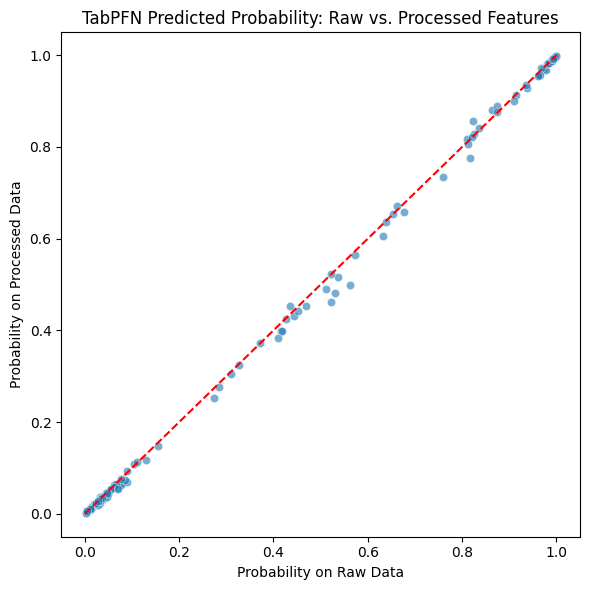

In [28]:
# 10) Visualize TabPFN probability invariance to feature scaling
import seaborn as sns
# Create DataFrame for plotting
df_invariance = pd.DataFrame({
    'Processed Proba': tpf_proc_proba,
    'Raw Proba': tpf_raw_proba
})
# Scatter plot
auto_fig = plt.figure(figsize=(6,6))
sns.scatterplot(
    data=df_invariance,
    x='Raw Proba',
    y='Processed Proba',
    alpha=0.6
)
# Diagonal line for reference
plt.plot([0,1], [0,1], 'r--')
plt.title('TabPFN Predicted Probability: Raw vs. Processed Features')
plt.xlabel('Probability on Raw Data')
plt.ylabel('Probability on Processed Data')
plt.tight_layout()
plt.show()

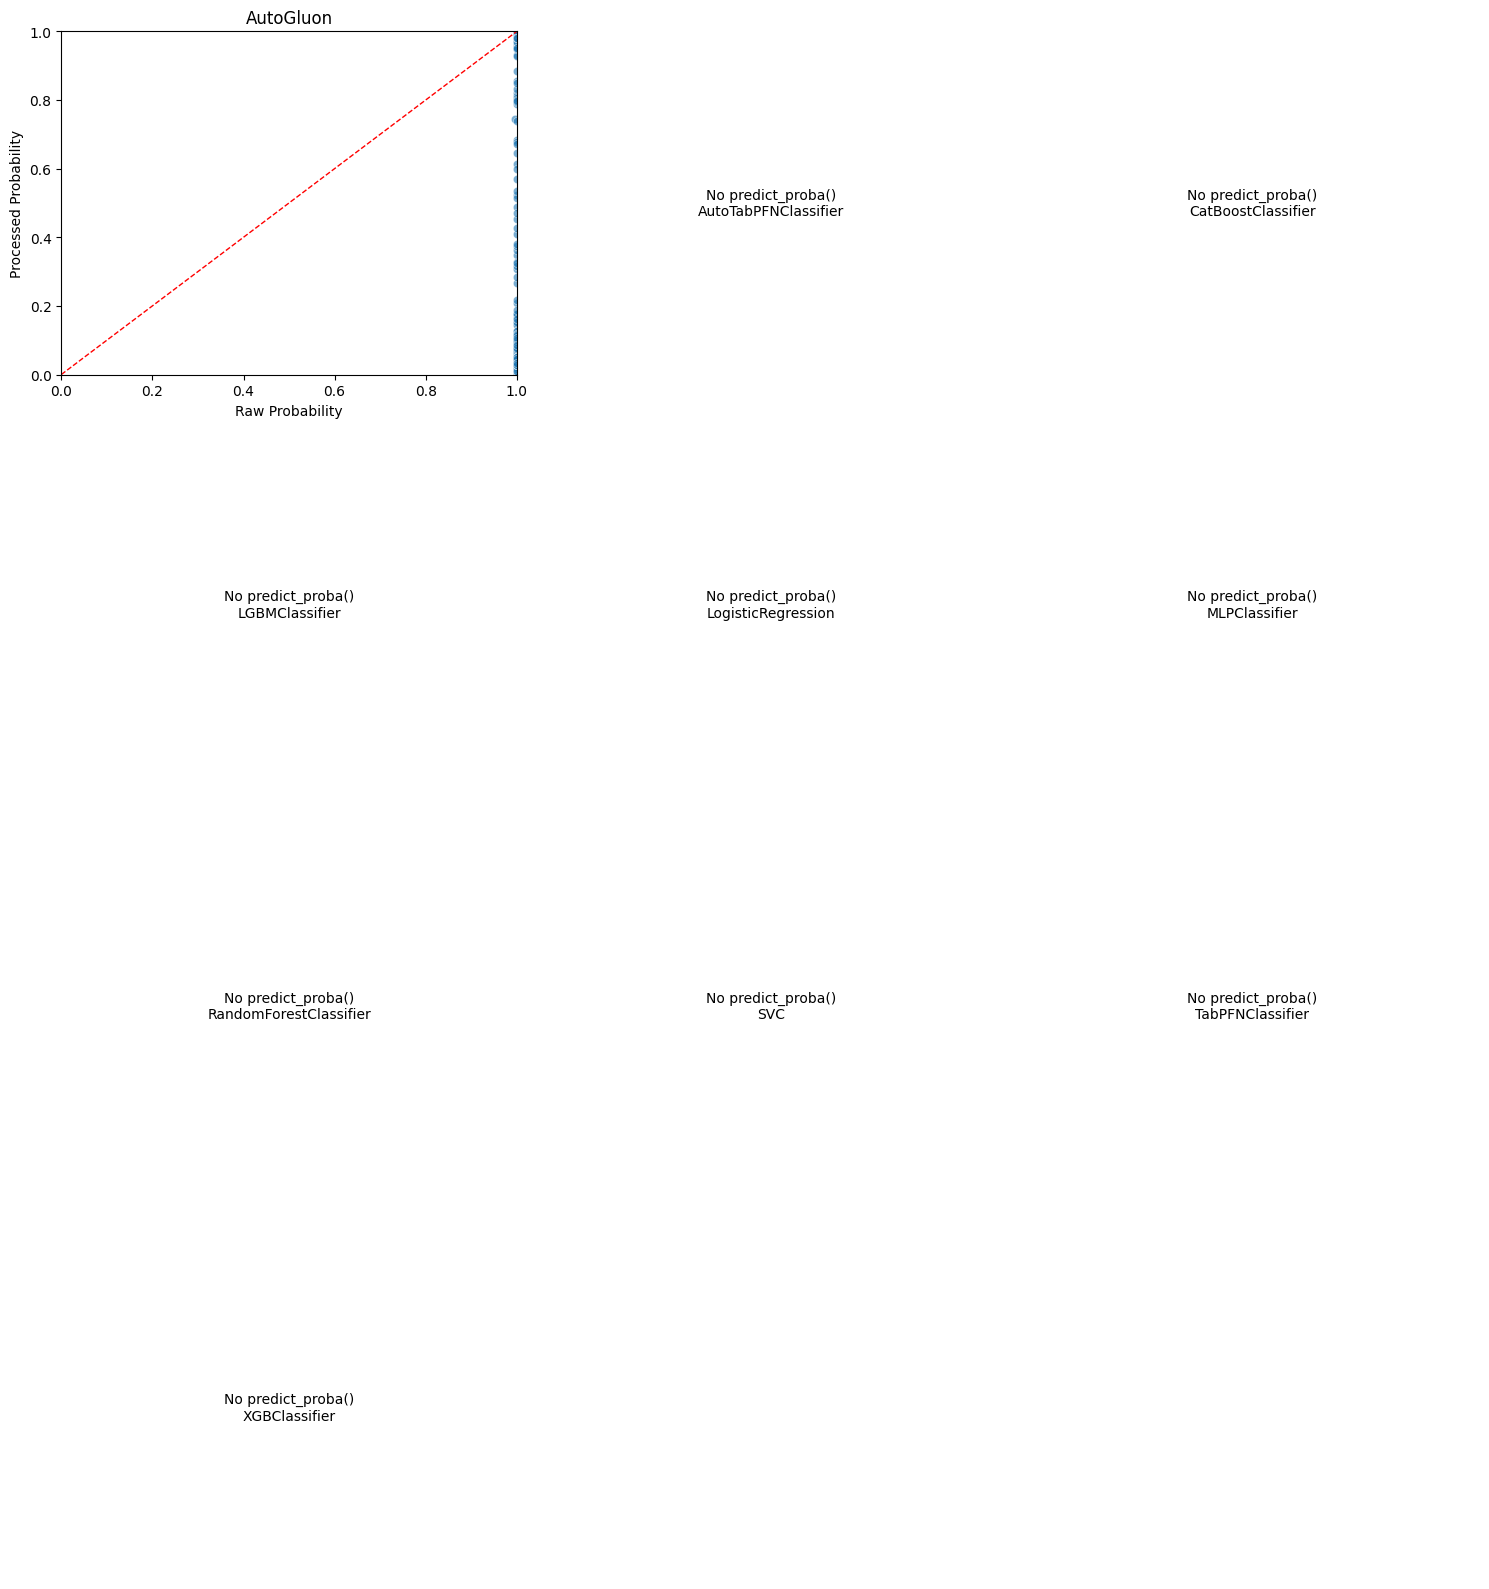

In [29]:
# Scatter: Raw vs Processed predicted probabilities (per model)

import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from autogluon.tabular import TabularPredictor

# --- Helper to get P(class=1) consistently ---
def prob_pos(model, X_df):
    """
    Return vector of P(class=1) for a fitted model on features X_df.
    Handles TabularPredictor (AutoGluon) and sklearn/catboost/lightgbm/xgboost/tabpfn.
    """
    # AutoGluon
    if isinstance(model, TabularPredictor):
        proba = model.predict_proba(X_df)
        if isinstance(proba, pd.DataFrame):
            # positive class is the last column for binary; if column '1' exists, prefer it
            if 1 in proba.columns:
                return proba[1].to_numpy()
            return proba.iloc[:, -1].to_numpy()
        elif isinstance(proba, pd.Series):
            return proba.to_numpy()
        else:
            return np.asarray(proba)

    # TabPFN expects numpy arrays
    from tabpfn import TabPFNClassifier, AutoTabPFNClassifier
    if isinstance(model, (TabPFNClassifier, AutoTabPFNClassifier)):
        return model.predict_proba(X_df.values)[:, 1]

    # CatBoost/LightGBM/XGBoost/sklearn generally accept DataFrame and return (n,2)
    proba = model.predict_proba(X_df)
    # Handle DataFrame/ndarray uniformly
    if isinstance(proba, pd.DataFrame):
        if 1 in proba.columns:
            return proba[1].to_numpy()
        return proba.iloc[:, -1].to_numpy()
    proba = np.asarray(proba)
    if proba.ndim == 2 and proba.shape[1] >= 2:
        return proba[:, -1]
    elif proba.ndim == 1:
        return proba
    else:
        raise ValueError("predict_proba returned unexpected shape")

# --- Gather fitted models ---
# Prefer a dict you may have created earlier during benchmarking
models = {}
if 'fitted_models' in globals() and isinstance(fitted_models, dict):
    # Expect keys like ('ModelName','processed') etc.; we want one instance per name
    # Prefer processed; if not available, fall back to raw (just to have an instance)
    names = sorted({k[0] for k in fitted_models.keys()})
    for name in names:
        models[name] = fitted_models.get((name, 'processed')) or fitted_models.get((name, 'raw'))

# Fallback to individual variables if present
# (Only adds if not already in `models`)
for name, var in [
    ('TabPFN', globals().get('tpf')),
    ('AutoTabPFN', globals().get('atpf')),
    ('AutoGluon', globals().get('predictor')),
    ('CatBoost', globals().get('cbm')),
    ('LightGBM', globals().get('lgm')),
    ('XGBoost', globals().get('xbm')),
    ('RandomForest', globals().get('rfm')),
    ('SVM', globals().get('svm')),
    ('MLP', globals().get('mlp')),
    ('LogisticRegression', globals().get('logreg')),
]:
    if var is not None and name not in models:
        models[name] = var

# Filter out any Nones (unfitted/missing)
models = {k: v for k, v in models.items() if v is not None}

if not models:
    raise RuntimeError("No fitted models found. Make sure you trained them and they are in variables or fitted_models dict.")

# --- Build plots ---
n = len(models)
cols = 3
rows = math.ceil(n / cols)
fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
axes = np.array(axes).reshape(-1)  # flatten even if rows/cols == 1

# Some libs (e.g., SVM without probability=True) may not support predict_proba
plot_idx = 0
for model_name, model in models.items():
    ax = axes[plot_idx]
    try:
        proc_proba = prob_pos(model, processed_X_test)
        raw_proba  = prob_pos(model, raw_X_test)

        df_inv = pd.DataFrame({'Processed Proba': proc_proba, 'Raw Proba': raw_proba})
        sns.scatterplot(data=df_inv, x='Raw Proba', y='Processed Proba', alpha=0.6, ax=ax)
        ax.plot([0, 1], [0, 1], linestyle='--', color='red', linewidth=1)
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        ax.set_title(model_name)
        ax.set_xlabel('Raw Probability'); ax.set_ylabel('Processed Probability')
    except Exception as e:
        # If no predict_proba, annotate the panel and continue
        ax.text(0.5, 0.5, f"No predict_proba()\n{type(model).__name__}",
                ha='center', va='center', transform=ax.transAxes)
        ax.set_axis_off()
    plot_idx += 1
    if plot_idx >= len(axes):
        break

# Hide any leftover empty subplots
for j in range(plot_idx, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

NameError: name 'cbm' is not defined

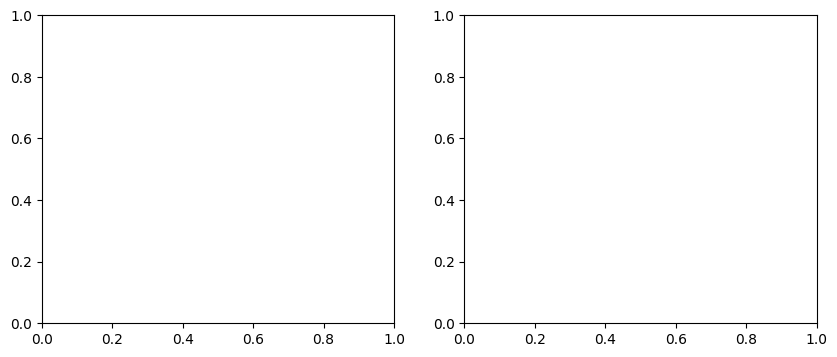

In [30]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(10,4))
for ax, (X_te, y_te, title) in zip(axes,
     [(processed_X_test, processed_y_test, 'Processed'),
      (raw_X_test,     raw_y_test,     'Raw')]):
    disp = ConfusionMatrixDisplay.from_estimator(
        cbm, X_te, y_te, ax=ax, cmap='Blues', normalize='true'
    )
    ax.set_title(f'CatBoost Confusion ({title})')
plt.tight_layout()

In [ ]:
# 11) Confusion Matrices for All Models
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from autogluon.tabular import TabularPredictor

models = {
    'TabPFN': tpf,
    'AutoTabPFN': atpf,
    'AutoGluon': predictor,
    'CatBoost': cbm,
    'LightGBM': lgm,
    'XGBoost': xbm
}

test_sets = {
    'Processed': (processed_X_test, processed_y_test),
    'Raw':       (raw_X_test,      raw_y_test)
}

for model_name, model in models.items():
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    for ax, (ds_name, (X_te, y_te)) in zip(axes, test_sets.items()):
        # Prepare predictions
        if isinstance(model, TabularPredictor):
            y_pred = model.predict(X_te)
        else:
            X_input = X_te.values if hasattr(X_te, 'values') else X_te
            y_pred = model.predict(X_input)
        # Plot confusion matrix
        ConfusionMatrixDisplay.from_predictions(
            y_te, y_pred, ax=ax, cmap='Blues', normalize='true'
        )
        ax.set_title(f"{model_name} ({ds_name})")
    plt.tight_layout()
    plt.show()

In [ ]:
# 12) Learning Curve for TabPFN Only
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

# Prepare data (processed features)
X_lc = X_processed.values
# y is the target vector defined earlier
try:
    y_lc = y.values
except:
    y_lc = y

# Learning curve settings
cv = 5
train_sizes = np.linspace(0.1, 1.0, 5)

# Use the TabPFN estimator
estimator = tpf  # TabPFNClassifier instance

# Compute learning curve
train_sizes_abs, train_scores, val_scores = learning_curve(
    estimator,
    X_lc,
    y_lc,
    cv=cv,
    train_sizes=train_sizes,
    scoring='accuracy',
    n_jobs=1
)
train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

# Plot learning curve
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(train_sizes_abs, train_mean, 'o-', label='Training Accuracy')
ax.plot(train_sizes_abs, val_mean, 'o-', label='Cross-Validation Accuracy')
ax.set_title('Learning Curve: TabPFN')
ax.set_xlabel('Training Examples')
ax.set_ylabel('Accuracy')
ax.legend(loc='best')
plt.tight_layout()
plt.show()

In [ ]:
# 13) Calibration Curves for All Models
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

models = {
    'TabPFN': tpf,
    'AutoTabPFN': atpf,
    'AutoGluon': predictor,
    'CatBoost': cbm,
    'LightGBM': lgm,
    'XGBoost': xbm
}

test_sets = {
    'Processed': (processed_X_test, processed_y_test),
    'Raw':       (raw_X_test,      raw_y_test)
}

for ds_name, (X_te, y_te) in test_sets.items():
    plt.figure(figsize=(10, 6))
    for model_name, model in models.items():
        # Get predicted probabilities
        if isinstance(model, TabularPredictor):
            proba = model.predict_proba(X_te).values[:, 1]
        else:
            proba = model.predict_proba(X_te.values if hasattr(X_te, 'values') else X_te)[:, 1]
        # Compute calibration curve
        frac_pos, mean_pred = calibration_curve(y_te, proba, n_bins=10)
        plt.plot(mean_pred, frac_pos, marker='o', label=model_name)
    # Plot reference line
    plt.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
    plt.title(f'Calibration Curves ({ds_name} Data)')
    plt.xlabel('Mean Predicted Probability')
    plt.ylabel('Fraction of Positives')
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()

In [ ]:
# 13) Calibration Curve for TabPFN Only
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

# Get TabPFN probabilities on processed and raw test sets
proc_proba = tpf.predict_proba(processed_X_test.values)[:, 1]
raw_proba  = tpf.predict_proba(raw_X_test.values)[:, 1]

# Compute calibration curves
y_proc = processed_y_test
math_frac_proc, math_mean_proc = calibration_curve(y_proc, proc_proba, n_bins=10)
y_raw = raw_y_test
math_frac_raw, math_mean_raw = calibration_curve(y_raw, raw_proba, n_bins=10)

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(math_mean_proc, math_frac_proc, 'o-', label='Processed')
plt.plot(math_mean_raw,  math_frac_raw,  's-', label='Raw')
plt.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
plt.title('Calibration Curve: TabPFN')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.legend()
plt.tight_layout()
plt.show()

import numpy as np
probas = tpf.predict_proba(processed_X_test.values)[:,1]
print(np.unique(np.round(probas, 4)))

In [ ]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

# Get TabPFN probabilities on processed and raw test sets
proc_proba = cbm.predict_proba(processed_X_test.values)[:, 1]
raw_proba  = cbm.predict_proba(raw_X_test.values)[:, 1]

# Compute calibration curves
y_proc = processed_y_test
math_frac_proc, math_mean_proc = calibration_curve(y_proc, proc_proba, n_bins=10)
y_raw = raw_y_test
math_frac_raw, math_mean_raw = calibration_curve(y_raw, raw_proba, n_bins=10)

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(math_mean_proc, math_frac_proc, 'o-', label='Processed')
plt.plot(math_mean_raw,  math_frac_raw,  's-', label='Raw')
plt.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
plt.title('Calibration Curve: Catboost')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# 14) Feature Importance and SHAP Summary for All Models
# import shap
# import pandas as pd
# import matplotlib.pyplot as plt

# # Define models dict
# models = {
#     'TabPFN': tpf,
#     'AutoTabPFN': atpf,
#     'AutoGluon': predictor,
#     'CatBoost': cbm,
#     'LightGBM': lgm,
#     'XGBoost': xbm
# }

# # Sample subset for KernelExplainer
# sample = processed_X_train.sample(n=min(100, len(processed_X_train)), random_state=42)

# for model_name, model in models.items():
#     print(f"### {model_name}")

#     if model_name == 'CatBoost':
#         # CatBoost feature importance
#         fi = model.get_feature_importance(prettified=True)
#         display(fi)
#         explainer = shap.TreeExplainer(model)
#         shap_values = explainer.shap_values(processed_X_train)
#         plt.title(f"{model_name} SHAP Summary")
#         shap.summary_plot(shap_values, processed_X_train)

#     elif model_name == 'LightGBM':
#         # LightGBM feature importance
#         fi = pd.DataFrame({
#             'feature': processed_X_train.columns,
#             'importance': model.feature_importances_
#         }).sort_values('importance', ascending=False)
#         display(fi)
#         explainer = shap.TreeExplainer(model)
#         shap_values = explainer.shap_values(processed_X_train)
#         plt.title(f"{model_name} SHAP Summary")
#         shap.summary_plot(shap_values, processed_X_train)

#     elif model_name == 'XGBoost':
#         # XGBoost feature importance
#         xgb_imp = model.get_booster().get_score(importance_type='weight')
#         fi = pd.DataFrame(list(xgb_imp.items()), columns=['feature','importance']).sort_values('importance', ascending=False)
#         display(fi)
#         explainer = shap.TreeExplainer(model)
#         shap_values = explainer.shap_values(processed_X_train)
#         plt.title(f"{model_name} SHAP Summary")
#         shap.summary_plot(shap_values, processed_X_train)

#     elif model_name == 'AutoGluon':
#         # AutoGluon feature importance
#         fi = model.feature_importance(processed_X_train)
#         display(fi)
#         # SHAP for AutoGluon depends on model type; skipping

#     else:
#         # TabPFN & AutoTabPFN: use KernelExplainer
#         def predict_proba_fn(X):
#             return model.predict_proba(X)[:,1]
#         explainer = shap.KernelExplainer(predict_proba_fn, sample.values)
#         shap_values = explainer.shap_values(sample.values, nsamples=100)
#         plt.title(f"{model_name} SHAP Summary")
#         shap.summary_plot(shap_values, sample, feature_names=processed_X_train.columns)
    
#     plt.show()

In [ ]:
import shap
import pandas as pd
import matplotlib.pyplot as plt

# Sample subset for KernelExplainer
sample = processed_X_train.sample(n=min(100, len(processed_X_train)), random_state=42)

# Define prediction function for TabPFN
predict_proba_fn = lambda X: tpf.predict_proba(X)[:,1]
# Initialize KernelExplainer
explainer = shap.KernelExplainer(predict_proba_fn, sample.values)
# Compute SHAP values on the sample
shap_values = explainer.shap_values(sample.values, nsamples=100)

# Plot SHAP summary for TabPFN
plt.title('TabPFN SHAP Summary')
shap.summary_plot(shap_values, sample, feature_names=processed_X_train.columns)
plt.show()

In [ ]:
# 15) Partial Dependence Plot for TabPFN
from sklearn.inspection import PartialDependenceDisplay

# Specify feature(s) for PDP (replace with your top feature names)
features = [processed_X_train.columns[0]]  # e.g. ['feature_name']

# Plot PDP for class probability of class 1
display = PartialDependenceDisplay.from_estimator(
    tpf,
    processed_X_train,
    features,
    target=1,
    kind='average',
    grid_resolution=50
)
plt.title(f"Partial Dependence of '{{features[0]}}' for TabPFN Class Probability")
plt.tight_layout()
plt.show()


# 🔧 Hyperparameter Tuning Add‑On (Paper‑aligned search spaces)

This section **keeps your existing code** and **adds** optional hyperparameter tuning for baselines,
using ranges inspired by the TabPFN paper's baseline search spaces (MLP, RF, SVM, CatBoost, XGBoost, LightGBM).  
- Uses `RandomizedSearchCV` with log‑uniform/uniform distributions.  
- You can control the number of iterations per model via `N_ITER` (or set per‑model).  
- Works with your existing dataset variables (`X_train`, `X_test`, `y_train`, `y_test`) and your preprocessing choices.

> Tip: If your data pipeline variables are named differently, just adapt the `X_train`, `X_test`, `y_train`, `y_test` references below.


In [ ]:

# %% [hparam-setup] Imports and helpers for tuning
import numpy as np
import pandas as pd
import warnings, time
from scipy.stats import loguniform, randint, uniform
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss

# Try to import all models here (some may already be imported in your earlier cells)
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression

import xgboost as xgb
import lightgbm as lgb
import catboost as cb

warnings.filterwarnings("ignore")

def safe_proba(estimator, X):
    try:
        p = estimator.predict_proba(X)
        return p.values if isinstance(p, pd.DataFrame) else np.asarray(p)
    except Exception:
        return None

def multi_roc_auc(y_true, y_prob):
    if y_prob is None: return np.nan
    if (y_prob.ndim == 1) or (y_prob.shape[1] == 2):
        pos = y_prob[:, 1] if y_prob.ndim > 1 else y_prob
        return roc_auc_score(y_true, pos)
    return roc_auc_score(y_true, y_prob, multi_class="ovr")


In [ ]:

# %% [hparam-spaces] Paper-inspired search spaces
# Ranges roughly mirror the figure you referenced.
search_spaces = {
    "MLP": {
        "hidden_layer_sizes": [(h,) for h in [64, 128, 256]] + [(128, 64), (256, 128), (256, 128, 64)],  # 1–3 layers
        "activation": ["relu", "tanh"],
        "alpha": loguniform(1e-7, 1e-1),
        "learning_rate_init": loguniform(1e-4, 10**-0.5),
        "early_stopping": [True, False],
        "max_iter": [300, 500, 800]
    },
    "RandomForest": {
        "n_estimators": randint(20, 201),
        "max_depth": randint(1, 46),
        "min_samples_split": [2, 5, 10],
        "max_features": ["sqrt", "log2", None]
    },
    "SVC": {
        "C": loguniform(1e-1, 1e2),      # {0.1,1,10,100} ~ log‑uniform
        "gamma": ["scale", "auto"],
        "kernel": ["rbf", "poly", "sigmoid"],
        "probability": [True]            # ensure probabilities
    },
    "CatBoost": {
        "learning_rate": loguniform(1e-5, 1),
        "depth": randint(3, 11),
        "l2_leaf_reg": loguniform(1, 10),
        "random_strength": randint(1, 21),
        "bagging_temperature": uniform(0.0, 1.0),
        "iterations": randint(100, 4001)
    },
    "XGBoost": {
        "learning_rate": loguniform(1e-7, 1),
        "max_depth": randint(1, 11),
        "subsample": uniform(0.2, 0.8),
        "colsample_bytree": uniform(0.2, 0.8),
        "colsample_bylevel": uniform(0.2, 0.8),
        "min_child_weight": loguniform(1e-16, 1e5),
        "alpha": loguniform(1e-16, 1e2),
        "lambda": loguniform(1e-16, 1e2),
        "gamma": loguniform(1e-16, 1e2),
        "n_estimators": randint(100, 4001)
    },
    "LightGBM": {
        "num_leaves": randint(5, 51),
        "max_depth": randint(3, 21),
        "learning_rate": loguniform(1e-3, 1),
        "n_estimators": randint(50, 2001),
        "min_child_weight": [1e-5, 1e-3, 1e-2, 1e-1, 1, 10, 1e2, 1e3, 1e4],
        "subsample": uniform(0.2, 0.6),            # 0.2–0.8
        "colsample_bytree": uniform(0.2, 0.6),     # 0.2–0.8
        "reg_alpha": [0, 1, 2, 5, 7, 10, 50, 100],
        "reg_lambda": [0, 1, 2, 5, 7, 10, 50, 100]
    }
}


In [ ]:

# %% [hparam-run] Run tuning (set N_ITER per model)
# Assumes you already have X_train, X_test, y_train, y_test from your previous cells.
# If your variable names differ, adapt here.

N_ITER = {
    "MLP": 25,
    "RandomForest": 25,
    "SVC": 25,
    "CatBoost": 25,
    "XGBoost": 25,
    "LightGBM": 25,
}

# Base estimators (sklearn-compatible)
estimators = {
    "MLP": MLPClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(random_state=42, n_jobs=-1),
    "SVC": SVC(random_state=42),
    "CatBoost": cb.CatBoostClassifier(verbose=False, random_seed=42),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42, tree_method="hist"),
    "LightGBM": lgb.LGBMClassifier(random_state=42)
}

results_hpo = []

for name, est in estimators.items():
    print(f"Tuning {name} ...")
    space = search_spaces[name]
    n_iter = N_ITER.get(name, 20)
    rs = RandomizedSearchCV(
        estimator=est,
        param_distributions=space,
        n_iter=n_iter,
        scoring="roc_auc_ovr",   # robust across binary/multiclass
        cv=3,
        n_jobs=-1,
        verbose=1,
        random_state=42,
        refit=True
    )
    t0 = time.time()
    rs.fit(X_train, y_train)
    fit_s = time.time() - t0

    best = rs.best_estimator_
    yhat = best.predict(X_test)
    yprob = safe_proba(best, X_test)

    row = dict(
        model=f"{name} (tuned)",
        acc=accuracy_score(y_test, yhat),
        roc_auc=multi_roc_auc(y_test, yprob),
        logloss=(log_loss(y_test, yprob) if yprob is not None else np.nan),
        fit_s=fit_s,
        best_params=rs.best_params_
    )
    results_hpo.append(row)

results_hpo = pd.DataFrame(results_hpo).sort_values(["roc_auc","acc"], ascending=[False, False]).reset_index(drop=True)
results_hpo


In [ ]:

# %% [hparam-save] Save tuned results and params
out_csv = "/mnt/data/hparam_tuned_results.csv"
results_hpo.to_csv(out_csv, index=False)
print("Saved tuned results to:", out_csv)

# Pretty print best params for quick copy-paste
for i, r in results_hpo.iterrows():
    print("\n===", r["model"], "===")
    for k, v in r["best_params"].items():
        print(f"{k}: {v}")
